Course: Diffuse and Stochastic Processes, Namiko Mitarai, NBI, University of Copenhagen

Assignment Part 2

Peter Resch, 26.5.2026

## Gillespie simulation of fermentation metabolism

In [73]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from tqdm import tqdm

r = np.random
r.seed(42)

#----------Initial parameters------

omega=1.0       #Volume of the system in liter
alpha=1.0       #metabolism rate from S -> H
gamma=1.0       #degrade factor of N population
lam=1.0         #growth factor of N population
mu=1.0          #metabolism factor of S population
#avogadro=6.022*10**23  #Avogadro's number

N=0             #lacto-acid bacteria LAB
S=10**-3         #mol Sugar molecules
H=10**-7         #mol H+ Ions, pH=7 (neutral)



total_time=1
num_simulations=3


#--------------------------------------------Functions--------------------------------------------
def give_pH(H):
    #H=H/avogadro
    pH=-np.log10(H)
    return pH

def rates_all_events(omega,lam, gamma, mu, S, H, N):
    growth = S*lam/omega
    degradation = H*gamma/omega
    metabolize = N*S*mu/omega
    return growth, degradation, metabolize

def event_time(K):
    r_tau=r.uniform()
    tau_event=-np.log(r_tau)/(K)   
    return tau_event

def event_type(g,d,m):
    K=g+d+m
    r_event=r.uniform()
    if r_event < g/K:
        return 'growth'
    elif g/K<r_event and r_event<(g+d)/K:
        return 'degradation'
    else:
        return 'metabolize'

def simulate_1_step(omega,lam, gamma, mu,alpha, S, H, N):
    g,d,m=rates_all_events(omega,lam, gamma, mu, S, H, N)
    K=g+d+m
    e_type=event_type(g,d,m)
    e_tau=event_time(K)
    #print(f"{e_type} after {e_tau}")

    if e_type=="growth":
        N+=1
    elif e_type=="degradation":
        if N>0:
            N-=1
    else:
        S-=1
        H+=1*alpha
    return [S,H,N],e_tau



def simulate_metabolism(omega,lam, gamma, mu,alpha, S, H, N, total_time):

    time = 0
    S_count = S
    H_count = H
    N_count = N

    S_array = [S]
    H_array = [H]
    N_array = [N]

    time_array = [time]

    while time < total_time:
        [S_count,H_count,N_count],tau=simulate_1_step(omega,lam, gamma, mu,alpha, S_count,H_count,N_count)

        S_array.append(S_count)
        H_array.append(H_count)
        N_array.append(N_count)

        time=time+tau
        time_array.append(time)
    
    return np.array(time_array), [np.array(S_array),np.array(H_array),np.array(N_array)]


In [74]:
#Testing
print(give_pH(H),f"for H{H}")
g,d,m=rates_all_events(omega,lam,gamma,mu,S,H,N)
K=g+m+d
print(g,d,m,K)
print("tau",event_time(K))
print(event_type(g,d,m))

a=simulate_1_step(omega,lam,gamma,mu,alpha,S,H,N)
print(S,H,N)
print(a)
print(S,H,N)


7.0 for H1e-07
0.001 1e-07 0.0 0.0010001
tau 981.9581595183328
growth
0.001 1e-07 0
([0.001, 1e-07, 1], np.float64(513.0126854352858))
0.001 1e-07 0


In [ ]:
simulation_times = []
simulation_counts_S = []
simulation_counts_N = []
simulation_counts_H = []

for _ in tqdm(range(num_simulations)):
    times, [counts_S,counts_H,counts_N] = simulate_metabolism(omega,lam, gamma, mu,alpha, S, H, N, total_time)
    #print(len(times))
    #print(len(counts_S))
    #print(counts_S[0])
    simulation_times.append(times)
    simulation_counts_S.append(counts_S)
    simulation_counts_N.append(counts_N)
    simulation_counts_H.append(counts_H)

print("Done!")

 67%|██████▋   | 2/3 [00:00<00:00,  6.11it/s]

2598
2579


100%|██████████| 3/3 [00:00<00:00,  6.31it/s]

2501
Done!


In [ ]:
simulation_counts_S

[array([1000, 1000,  999, ...,  410,  410,  410], shape=(2598,)),
 array([1000, 1000, 1000, ...,  415,  414,  413], shape=(2579,)),
 array([1000, 1000, 1000, ...,  456,  456,  456], shape=(2501,))]

In [ ]:
def n_at_time_t_per_simulation(time_array, event_count_array, t):
    if t < time_array[0]:
        return 0
    
    # Find the index of the last time point that is less than or equal to t
    index = np.searchsorted(time_array, t, side='right') - 1
    n_at_t = event_count_array[index]
    return n_at_t

n_at_time_t_per_simulation(simulation_times[0], simulation_counts_S[0], 0.35)

np.int64(596)

## Plot trajectories

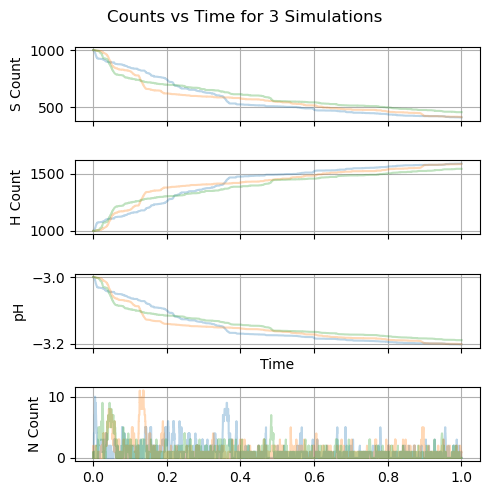

In [ ]:
#plot counts vs time for each simulation
fig,ax=plt.subplots(4, 1, figsize=(5, 5),sharex=True)
for i in range(3):
    ax[0].plot(simulation_times[i], simulation_counts_S[i], alpha=0.3)
    ax[1].plot(simulation_times[i], simulation_counts_H[i], alpha=0.3)
    ax[2].plot(simulation_times[i], give_pH(simulation_counts_H[i]), alpha=0.3)
    ax[3].plot(simulation_times[i], simulation_counts_N[i], alpha=0.3)

ax[2].set_xlabel('Time')

fig.suptitle(rf'Counts vs Time for {num_simulations} Simulations')

ax[0].set_ylabel('S Count')
ax[1].set_ylabel('H Count')

ax[2].set_ylabel('pH')
ax[3].set_ylabel('N Count')

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

plt.tight_layout()
fig.savefig('count_vs_time.png', dpi=300)

## Simulate 100 trajectories

In [ ]:
def calc_mean(time_simulations, event_simulations, t):
    n_values = []
    for time_array, event_count_array in zip(time_simulations, event_simulations):
        n_at_t = n_at_time_t_per_simulation(time_array, event_count_array, t)
        n_values.append(n_at_t)
    return np.mean(n_values)

def calc_variance(time_simulations, event_simulations, t):
    n_values = []
    for time_array, event_count_array in zip(time_simulations, event_simulations):
        n_at_t = n_at_time_t_per_simulation(time_array, event_count_array, t)
        n_values.append(n_at_t)
    return np.var(n_values)

def coefficient_of_variation(mean_array,var_array,steady_state_start_time=120):
    mean_subset = mean_array[steady_state_start_time:]
    var_subset = var_array[steady_state_start_time:]
    return np.sqrt(np.mean(var_subset))/np.mean(mean_subset)

In [ ]:
aligned_event_times = np.arange(0, total_time, 1)

S_mean_array = []
H_mean_array = []
N_mean_array = []

S_variance_array = []
H_variance_array = []
N_variance_array = []


for t in aligned_event_times:
    S_mean_array.append(calc_mean(simulation_times, simulation_counts_S, t))
    H_mean_array.append(calc_mean(simulation_times, simulation_counts_H, t))
    N_mean_array.append(calc_mean(simulation_times, simulation_counts_N, t))

    S_variance_array.append(calc_variance(simulation_times, simulation_counts_S, t))
    H_variance_array.append(calc_variance(simulation_times, simulation_counts_H, t))
    N_variance_array.append(calc_variance(simulation_times, simulation_counts_N, t))

In [ ]:
#plot mRNA count vs time for each simulation
fig,ax=plt.subplots(figsize=(8, 4))
for i in range(100):
    ax.plot(time_simulations[i], mRNA_simulations[i], alpha=0.1)
ax.plot(mRNA_all_event_times, mRNA_mean_array, label='Mean over 100 simulations', color='black', linewidth=2)

ax.plot(mRNA_all_event_times, mRNA_variance_array, label='Variance over 100 simulations', color='red', linewidth=2)
ax.set_xlim(0, total_time)
ax.set_xlabel('Time')
ax.set_ylabel('mRNA Count')
ax.set_title(rf'mRNA Count vs Time, $\Omega={omega}, \alpha={alpha}, \Gamma_1={gamma_1}$')
ax.legend()
plt.grid()
plt.tight_layout()
fig.savefig('mRNA_count_vs_time.png', dpi=300)